<a href="https://colab.research.google.com/github/richaa357/Titanic_dataset/blob/main/decision_tree_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [29]:
df=sns.load_dataset("titanic")
# view the dataset
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [31]:
df.shape

(891, 15)

In [32]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [33]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


<Axes: xlabel='class', ylabel='count'>

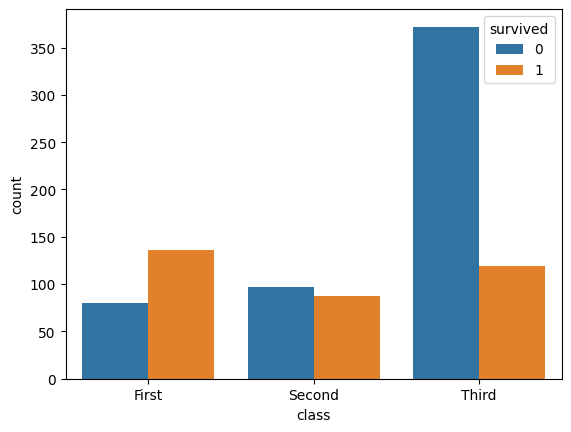

In [34]:
# EDA
# survived is the output column
sns.countplot(data=df,x="class",hue="survived")


<Axes: xlabel='age', ylabel='Count'>

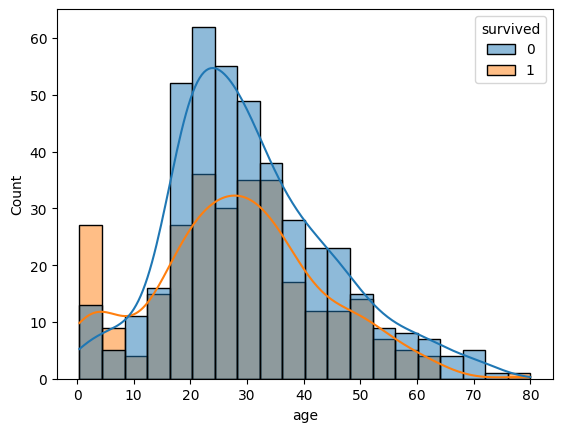

In [35]:
sns.histplot(data=df,x="age",hue="survived",kde=True)

<Axes: xlabel='sex', ylabel='count'>

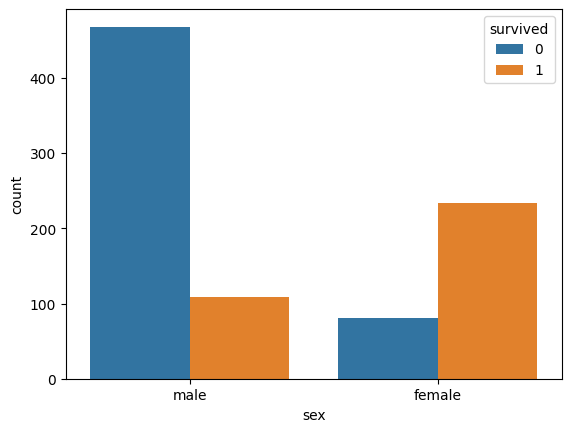

In [36]:
sns.countplot(data=df,x="sex",hue="survived")

In [37]:
df.drop(columns=["class","who","deck","embark_town","alive","alone","adult_male"],inplace=True,axis=1)



In [38]:
df.shape

(891, 8)

<Axes: xlabel='age'>

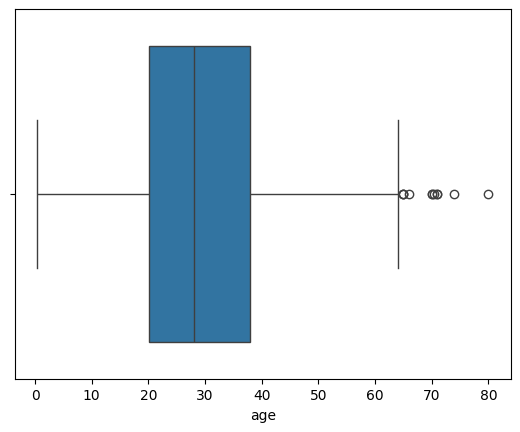

In [39]:

# checking outliers
sns.boxplot(x=df["age"])

In [40]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="median")
df[["age"]]=imputer.fit_transform(df[["age"]])


In [41]:
imputer=SimpleImputer(strategy="most_frequent")
df[["embarked"]]=imputer.fit_transform(df[["embarked"]])
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0


In [42]:
# one hot encoding to convert categorical columns" sex "and" embarked "to numerical col
df=pd.get_dummies(df,columns=["sex","embarked"],drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df.head()

,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


In [43]:
df.shape

(891, 9)

In [44]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=["survived"])
Y=df["survived"]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion="gini",max_depth=3,random_state=42)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(Y_test,Y_pred))
print(confusion_matrix(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.7988826815642458
[[92 13]
 [23 51]]
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [45]:
print(model.score(X_train,Y_train))
print(model.score(X_test,Y_test))

0.8342696629213483
0.7988826815642458


[Text(0.5, 0.875, 'sex_male <= 0.5\ngini = 0.469\nsamples = 712\nvalue = [444, 268]\nclass = survived'),
 Text(0.25, 0.625, 'pclass <= 2.5\ngini = 0.386\nsamples = 245\nvalue = [64, 181]\nclass = not survived'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'age <= 2.5\ngini = 0.074\nsamples = 130\nvalue = [5, 125]\nclass = not survived'),
 Text(0.0625, 0.125, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]\nclass = survived'),
 Text(0.1875, 0.125, 'gini = 0.061\nsamples = 128\nvalue = [4, 124]\nclass = not survived'),
 Text(0.375, 0.375, 'fare <= 23.35\ngini = 0.5\nsamples = 115\nvalue = [59.0, 56.0]\nclass = survived'),
 Text(0.3125, 0.125, 'gini = 0.486\nsamples = 94\nvalue = [39, 55]\nclass = not survived'),
 Text(0.4375, 0.125, 'gini = 0.091\nsamples = 21\nvalue = [20, 1]\nclass = survived'),
 Text(0.75, 0.625, 'age <= 6.5\ngini = 0.303\nsamples = 467\nvalue = [380, 87]\nclass = survived'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'sibsp <= 2.5\ngini = 0.434\nsamples = 22\n

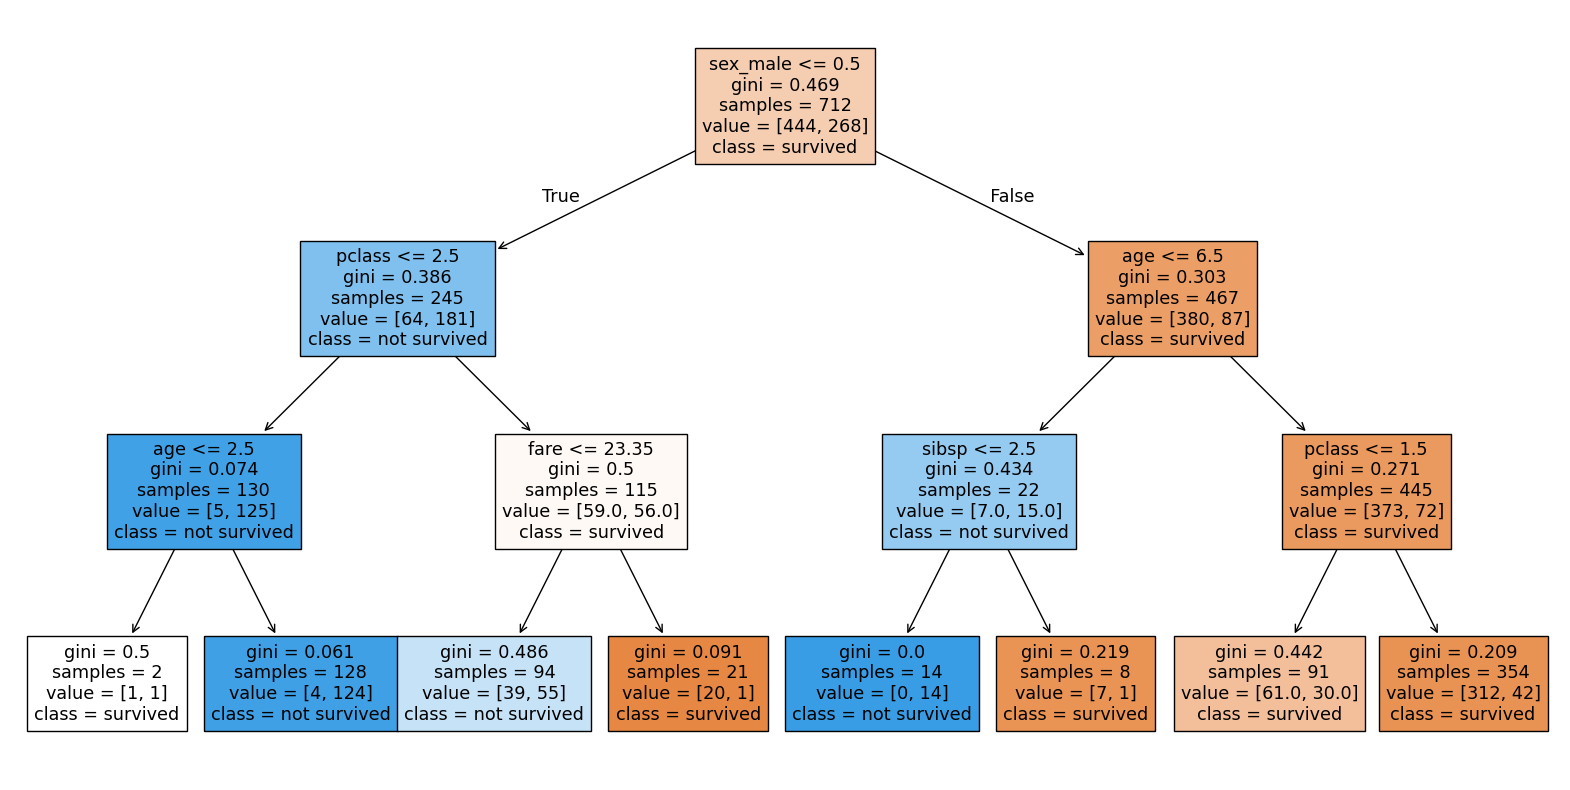

In [46]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model,filled=True,feature_names=X.columns,class_names=["survived","not survived"])

In [48]:
new_passenger=pd.DataFrame({"pclass":[3],
"age"	:[60],
"sibsp":	[1],
"parch":	[0],
"fare":[7.9250],
"sex_male":[0],
"embarked_Q":[1],
"embarked_S":[0]})
print(model.predict(new_passenger))

[1]
